In [32]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict
import os


In [33]:
load_dotenv()

True

In [34]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,    
    api_key=os.getenv("GROQ_API_KEY"),
)

In [35]:
# create state

class LLMState(TypedDict):
    question: str
    answer: str

In [36]:
def llm_qa(state: LLMState) -> LLMState:
    # extract question from state
    question = state['question']

    # form a prompt 
    prompt = f"Answer the following question: {question}"

    # ask the question to the llm
    answer = model.invoke(prompt).content

    # update the answer in the staticmethod
    state['answer'] = answer

    return state

In [37]:
# create graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()

In [38]:
# initial state
initial_state = {'question':'How far is the moon from the earth?'}

final_state = workflow.invoke(initial_state)

print(final_state['answer'])

The Moon orbits Earth at an average distance of **about 384 400 kilometers (≈238 900 miles)**.  

Because its orbit is slightly elliptical, the actual distance varies:

| Position | Approximate distance from Earth |
|----------|---------------------------------|
| **Perigee** (closest point) | ~363 300 km (≈225 600 mi) |
| **Apogee** (farthest point) | ~405 500 km (≈251 900 mi) |

So the Moon is roughly 384 000 km away on average, ranging between about 363 000 km and 406 000 km over the course of each orbit.  

For perspective, light (or radio signals) takes **about 1.28 seconds** to travel from the Moon to Earth at that average distance.


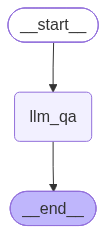

In [39]:
workflow